Created 6/31/2026

Created to play around with the simulated SMARTS light curves and spinspotter.

Notes:
- Smarts LCs don't contain any nans. Data gaps are filled with 1s.

In [280]:
# Imports
import warnings
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import spinspotter as ss
import lightkurve as lk

from scipy import stats
from astropy import units as u
from astropy.timeseries import TimeSeries, aggregate_downsample
from astropy.time import Time
from statsmodels.tsa.stattools import acf


In [275]:
# Helper Functions (put finished helper functions here)
def to_even_cadence(time, flux, flux_err=None, timestep=1800):
    """
    Maps a light curve onto an evenly-spaced time grid at the given cadence.
    Each original point is placed at its nearest grid index (no averaging);
    timesteps with no matching data point are filled with NaN.

    Args:
        time (array): time stamps, in days.
        flux (array): flux values.
        flux_err (array): flux_err values, if available.
        timestep (float): cadence of the output grid, in seconds (default 1800 s).

    Returns:
        time_even (array): evenly-spaced time stamps, in days.
        flux_even (array): flux values on the even grid, with NaN for gaps.
        flux_err (array): flux_err values on the even grid, if provided.
    """
    time = np.asarray(time, dtype=float)
    flux = np.asarray(flux, dtype=float)
    dt = timestep / 86400.0  # seconds -> days    
    
    # sanity check: does the requested timestep match the data's actual cadence?
    diffs = np.round(np.diff(time) * 86400).astype(int)
    values, counts = np.unique(diffs, return_counts=True)
    mode_timestep = values[np.argmax(counts)]
    if not np.isclose(timestep, mode_timestep, rtol=0.01):
        warnings.warn(
            f"Requested timestep ({timestep} s) does not match the mode "
            f"cadence of the input time array ({mode_timestep} s). "
            "The wrong timestep may have been provided."
        )

    n_bins = int(round((time[-1] - time[0]) / dt)) + 1
    time_even = time[0] + np.arange(n_bins) * dt

    idx = np.round((time - time[0]) / dt).astype(int)
    valid = (idx >= 0) & (idx < n_bins)

    flux_even = np.full(n_bins, np.nan)
    flux_even[idx[valid]] = flux[valid]
    
    if flux_err is not None:
        flux_err_even = np.full(n_bins, np.nan)
        flux_err_even[idx[valid]] = flux_err[valid]
        return time_even, flux_even, flux_err_even
        
    return time_even, flux_even

def bin_lc(time, flux, flux_err=None, binsize=1800):
    """
    Bins a timeseries to the desired cadence. Works much faster than Lightkurve's built in binning function.

    Args:
        time (:obj:`array`): time stamps of the lightcurve.
        flux (:obj:`array`): flux values of the lightcurve.
        flux_err (:obj:`array`): flux error values of the lightcurve.
        binsize (:obj:`float`): the size of the bins, in units of seconds.

    Returns:
    Two parameters, or three if a flux_err is also provided.

        - time_bin (:obj:`array`): binned time stamps of the lightcurve.
        - flux_bin (:obj:`array`): binned flux values of the lightcurve.
        - flux_err_bin (:obj:`array`): binned flux errors values of the lightcurve. Only returned if an array is passed to flux_err.
    """
    time_bin = np.arange(time[0], time[-1], binsize / 86400.0) # seconds -> days 
    flux_bin = stats.binned_statistic(time, flux, bins=time_bin)[0]

    # If flux_err is populated, assume the errors combine as the root-mean-square
    if flux_err is not None:
        # define a function to calculate the root mean square error of each bin
        rmse_func = (lambda x: np.sqrt(np.nansum(np.square(x))) / len(np.atleast_1d(x))
                    if np.any(np.isfinite(x))
                    else np.nan)
        flux_err_bin = stats.binned_statistic(time, flux_err, statistic=rmse_func, bins=time_bin)[0]
        return time_bin[:-1], flux_bin, flux_err_bin

    return time_bin[:-1], flux_bin



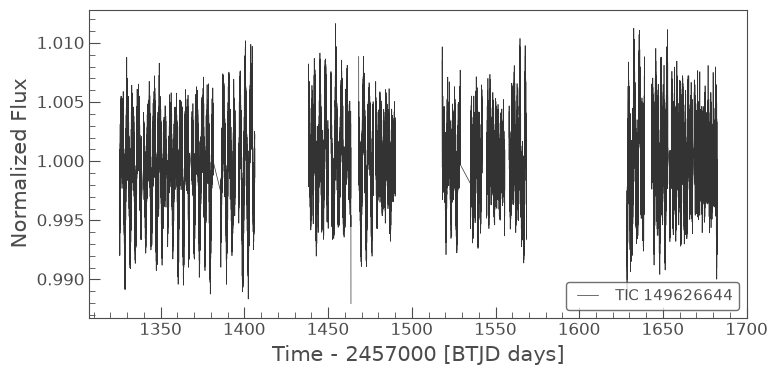

In [261]:
# open a TESS LC as a test case
# TIC 149626644, TESS Sectors 1-8
search_result = lk.search_lightcurve('TIC 149626644', mission='TESS', cadence='short', author='SPOC')
# print(search_result)

# Download
collection = search_result.download_all()

# extract
lct = collection.stitch().normalize()
time1 = lct.time.mjd - lct.time.mjd[0]
flux1 = lct.flux.value
flux_err1 = lct.flux_err.value

# Plot, to make sure it looks correct
lct.plot()
plt.show()



0.9983000159263611
Filename: data/tess/001/smarts-tess-v1.0-005025.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      32   ()      
  1  LIGHTCURVE    1 BinTableHDU     15   17520R x 2C   [E, E]   
  2  WAVELET       1 ImageHDU        10   (64, 64)   uint8   


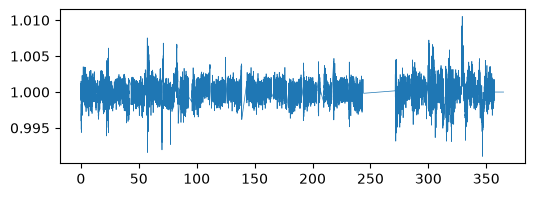

In [247]:
# open a SMARTS light curve to use as a test case
fits_path = "data/tess/001/smarts-tess-v1.0-005025.fits"
hdul = fits.open(fits_path)
print(hdul[0].header['PERIOD'])
hdul.info()

# extract the light curve data from the FITS file
lc = hdul["LIGHTCURVE"].data
time = lc["time"]
flux = lc["flux"]
flux_err = ...   # some light curves may have errors, others may not
expected_period = hdul[0].header['PERIOD']
cadence = hdul[0].header['XPOSURE']

# turn into an astropy timeseries object
# ts = TimeSeries(time=Time(time, format='mjd', scale='utc'),
#                 data={'flux': flux * u.dimensionless_unscaled,
#                       'flux_err': [np.nan]*len(flux) * u.dimensionless_unscaled},
#                 names=('flux', 'flux_err'))
ts = TimeSeries(time=Time(time, format='mjd', scale='utc'),
                data={'flux': flux * u.dimensionless_unscaled,},
                names=(('flux',)))

plt.figure(figsize=[6,2])
plt.plot(ts['time'].mjd, ts['flux'], lw=0.5);

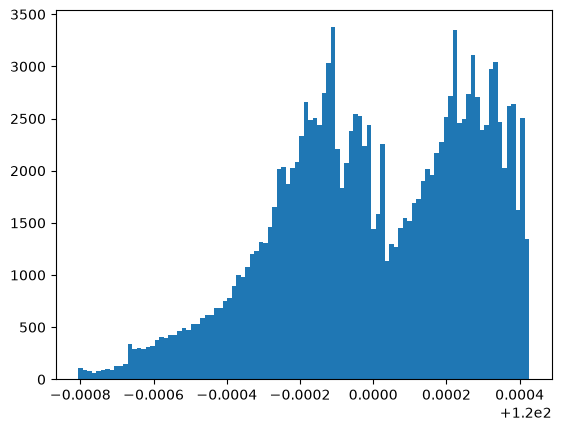

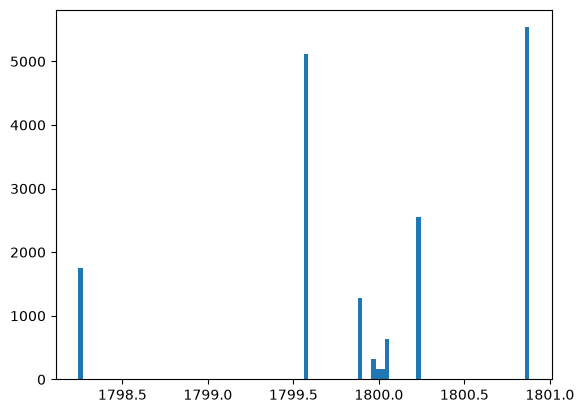

In [236]:
# check the typical time step between timesteps points
# TESS
timesteps = (time1[1:] - time1[:-1]) * 24 * 60 * 60
plt.hist(timesteps[timesteps < 140], bins=100, histtype='stepfilled');
# plt.xlim([110,130])
plt.show()

# SMARTS
timesteps = (time[1:] - time[:-1]) * 24 * 60 * 60
plt.hist(timesteps, bins=100, histtype='stepfilled');
plt.show()

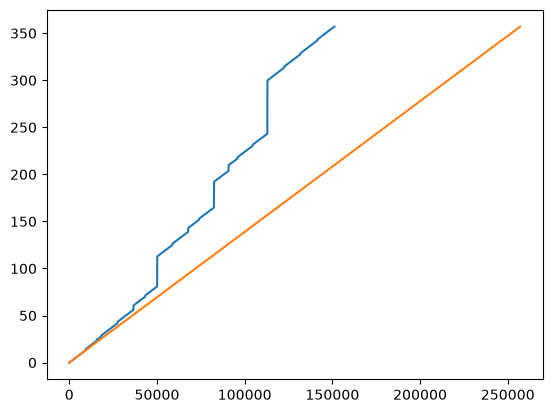

In [ ]:
# test the even cadence function on the two LCs
# SMARTS
# introduce an artificial gap to prove nan-filling works
t = np.delete(time, np.arange(100, 150))
f = np.delete(flux, np.arange(100, 150))
te, fe = to_even_cadence(t, f, timestep=1800)
print('input points:', len(t), 'output points:', len(te))
print('nan count:', np.isnan(fe).sum(), '(expected 50 from the artificial gap)')
print('matches original at non-gap index 0:', fe[0] == flux[0])
print('max abs time diff vs expected cadence:', np.max(np.abs(np.diff(te) - 1800/86400)))

# plot to test
plt.plot(time, flux, lw=0.5, marker='o', markersize=2)
plt.plot(te, fe, lw=0.5, marker='o', markersize=2)
plt.xlim([240,255])
plt.show()

# TESS
te1, fe1, fee1 = to_even_cadence(time1, flux1, flux_err=flux_err1, timestep=120)
plt.plot(time1)
plt.plot(te1)
plt.show()

(20.0, 22.0)

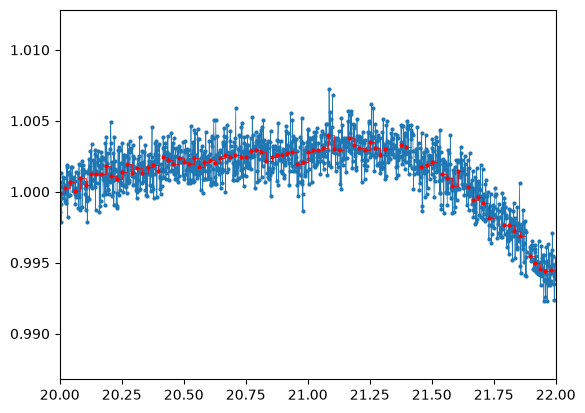

In [276]:
# now try binning if we want that
tb1, fb1, feb1 = bin_lc(te1, fe1, flux_err=fee1, binsize=1800)

plt.plot(te1, fe1, lw=0.5, marker='o', markersize=2)
plt.plot(tb1, fb1, 'r-', drawstyle='steps-post', lw=0.5, marker='o', markersize=2)
plt.xlim([20,22])

In [ ]:
nlags

np.float64(17472.0)

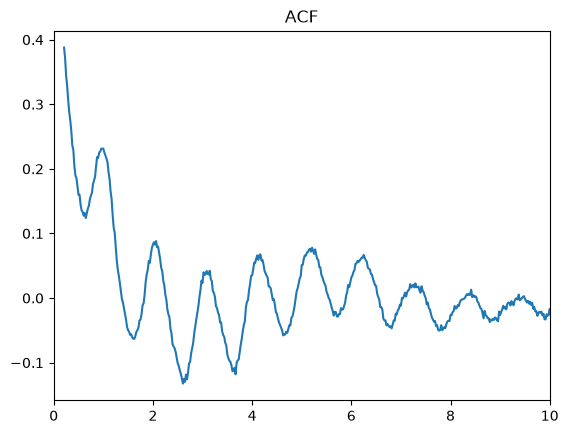

In [304]:
# SMARTS
# median normalize
fn = fe - 1.

# calculate the ACF
nlags = ss.days_to_bins(np.floor(te[-1] - te[0]), 1800)
acf_corr = acf(fn, missing='conservative',nlags=nlags,fft=True)
lag_times = ss.bins_to_days(np.arange(len(acf_corr)), 1800)

plt.plot(lag_times[10:], acf_corr[10:])
plt.xlim([0,10])
# plt.ylim([-.2,.3])
plt.title('ACF')
plt.show()


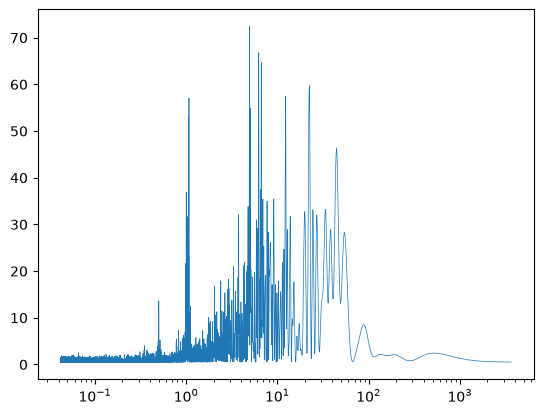

In [312]:
# FFT of the ACF
# to get the correct period scale in days, need to divide by the number of bins in a day
coeff = 10
corr_fft = np.real(np.fft.rfft(acf_corr, n=coeff*len(acf_corr)))
fft_period = np.divide(1., np.fft.rfftfreq(coeff*len(acf_corr))[1:]) / ((60*60*24) / 1800)

# we're only interested in the positive half of the fft
snip = np.where((fft_period >= 0) & (fft_period <= len(acf_corr)))
fft_period = fft_period[snip]
corr_fft = corr_fft[snip]

plt.plot(fft_period, corr_fft, lw=0.5)
plt.xscale('log')

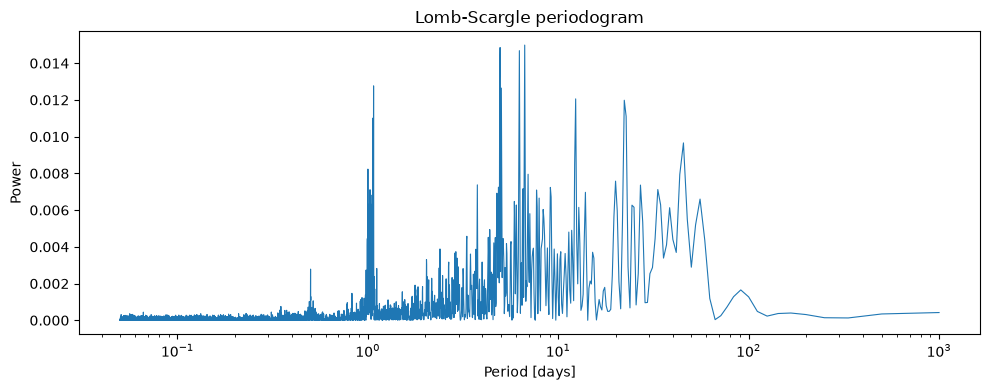

In [308]:
# LS of the light curve
import numpy as np
from astropy.timeseries import LombScargle

import matplotlib.pyplot as plt

mask = np.isfinite(time) & np.isfinite(flux)
t = time[mask]
y = flux[mask]

ls = LombScargle(t, y)
freqs = np.linspace(1 / 1000, 1 / 0.05, 20000)
power = ls.power(freqs, normalization="standard")

periods = 1 / freqs

plt.figure(figsize=(10, 4))
plt.plot(periods, power, lw=0.8)
plt.xscale("log")
plt.xlabel("Period [days]")
plt.ylabel("Power")
plt.title("Lomb-Scargle periodogram")
plt.tight_layout()
plt.show()

np.float64(1.0)

/Users/rjholco1/miniforge3/envs/ss_sandbox/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 35038 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/rjholco1/miniforge3/envs/ss_sandbox/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 35038 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


(20.0, 22.0)

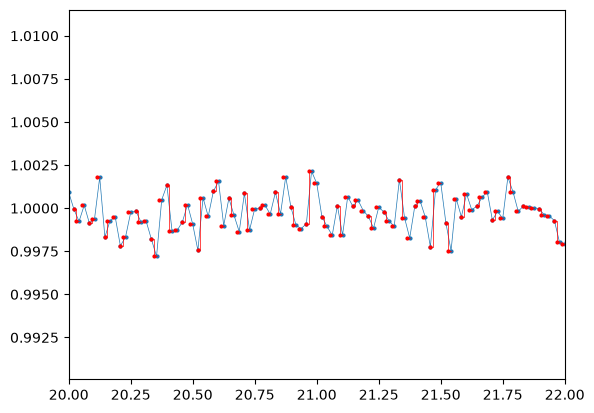

In [170]:
ts_binned = aggregate_downsample(ts, time_bin_size=900 * u.s)
# plt.plot(ts.time, ts.data['flux'])
plt.plot(ts['time'].mjd, ts['flux'], lw=0.5, marker='o', markersize=2)
plt.plot(ts_binned.time_bin_start.mjd, ts_binned['flux'], 'r-', drawstyle='steps-post', lw=0.5, marker='o', markersize=2)
plt.xlim([20,22])

(np.int64(5838), np.int64(0))

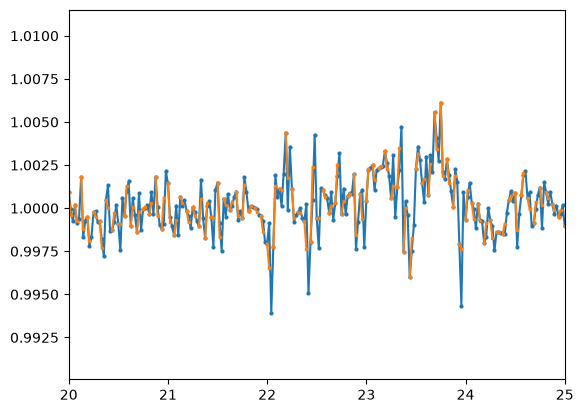

In [ ]:
# mess around with binning
from astropy.timeseries import aggregate_downsample
ts_binned = aggregate_downsample(ts_folded, time_bin_size=0.03 * u.day)

ts_binned

time_even, flux_even = ss.bin_lc(time, flux, bs=cadence,)
plt.plot(time, flux, marker='o', markersize=2)#, lw=0.5)
plt.plot(time_even, flux_even, marker='s', markersize=2)#, lw=0.5)
# plt.plot(te, fe, marker='s', markersize=2)#, lw=0.5)
plt.xlim([20,25])

sum(np.isnan(flux_even)), sum(np.isnan(flux))

# Ignore Below Here

In [33]:
print(repr(hdul[0].header))

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE-BEG= '2018-07-25T19:29:42.708Z' / ISO-8601 formatted DateTime for obs start
DATE-END= '2019-07-17T20:29:29.973Z' / ISO-8601 formatted DateTime for obs end  
DATE-AVG= '2019-01-20T07:59:36.3405Z' / ISO-8601 formatted DateTime for obs mid 
DOI     = '10.17909/davg-m919' / Digital Object Identifier for HLSP data        
HLSPID  = 'SMARTS  '           / identifier for this HLSP collection            
HLSPLEAD= 'Zachary R. Claytor' / HLSP project lead                              
HLSPNAME= 'Stellar Magnetism, Activity, and Rotation with Time Series' / title  
HLSPTARG= 'SMARTS-TESS-v1.0-005035' / target designation                        
HLSPVER =                  1

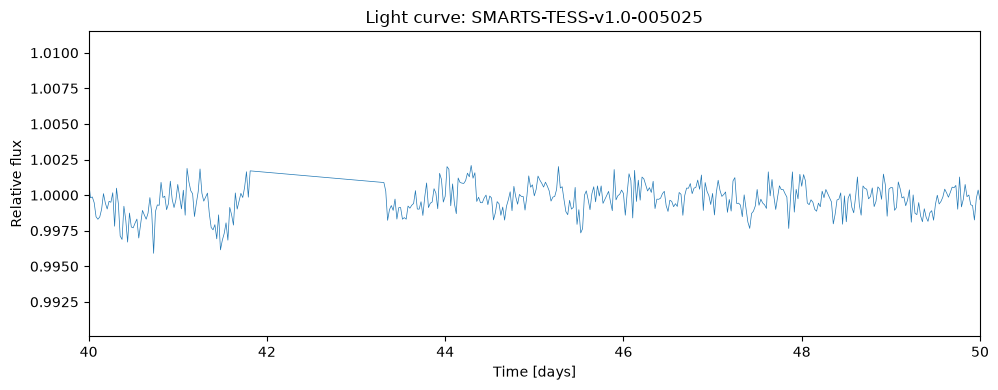

In [42]:
lc = hdul["LIGHTCURVE"].data
time = lc["time"]
flux = lc["flux"]

plt.figure(figsize=(10, 4))
plt.plot(time, flux, lw=0.5)
plt.xlabel("Time [days]")
plt.ylabel("Relative flux")
plt.title(f"Light curve: {hdul[0].header['HLSPTARG']}")
plt.tight_layout()
plt.xlim([40,50])
plt.show()

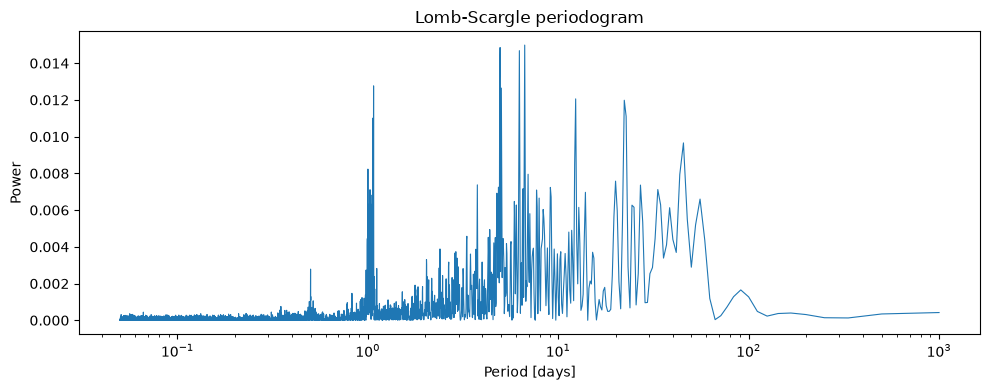

In [43]:
import numpy as np
from astropy.timeseries import LombScargle

import matplotlib.pyplot as plt

mask = np.isfinite(time) & np.isfinite(flux)
t = time[mask]
y = flux[mask]

ls = LombScargle(t, y)
freqs = np.linspace(1 / 1000, 1 / 0.05, 20000)
power = ls.power(freqs, normalization="standard")

periods = 1 / freqs

plt.figure(figsize=(10, 4))
plt.plot(periods, power, lw=0.8)
plt.xscale("log")
plt.xlabel("Period [days]")
plt.ylabel("Power")
plt.title("Lomb-Scargle periodogram")
plt.tight_layout()
plt.show()

In [72]:
# spinspotter set up
def custom_calc_pgi(acf, bs=30*60, pgi_in_days=-1):    
    """
    docstring. The default pgi-finding funciton, using the FFT of the acf.
    Inputs: acf - and acf
    
    Outputs: pgi - the index in the acf of the initial period guess in units of lags
             results - dictionary of other relevant paramters from the pgi-finding code
    """
    results = {}
    pgi = int(np.round(ss.days_to_bins(pgi_in_days, bs=bs)))
    
    # if the pgi is nan or is negative, then fail
    if (np.isnan(pgi)) or pgi < 0 :
        results['fail'] = True
        return np.nan, results
    else:
        results['fail'] = False
    
    return pgi, results

In [77]:
# try out spinspotter
import spinspotter as ss
import lightkurve as lk

lc = lk.LightCurve(time[:(56*48)], flux[:(56*48)])
lc.meta['TARGETID'] = 102938
lc.meta['OBJECT'] = 102938

pgi = 1*24*60/30
bs = 30*60

# fr, pr = ss.process_LightCurve(lc, bs=30*60)

prot_prior_func_kwargs = {'pgi_in_days':1}
fr, pr = ss.process_LightCurve(lc, bs=bs, 
                                prot_prior='custom', prot_prior_func=custom_calc_pgi, 
                                prot_prior_func_kwargs=prot_prior_func_kwargs)


/Users/rjholco1/miniforge3/envs/ss_sandbox/lib/python3.12/site-packages/lightkurve/lightcurve.py:363: LightkurveDeprecationWarning: passing flux as a positional argument is deprecated, please use ``flux=...`` instead.
  warnings.warn(


[0.9736356  1.02450371 1.03649617 1.02219506 1.06255229]


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'ACF'}, xlabel='Lag (days)', ylabel='ACF'>)

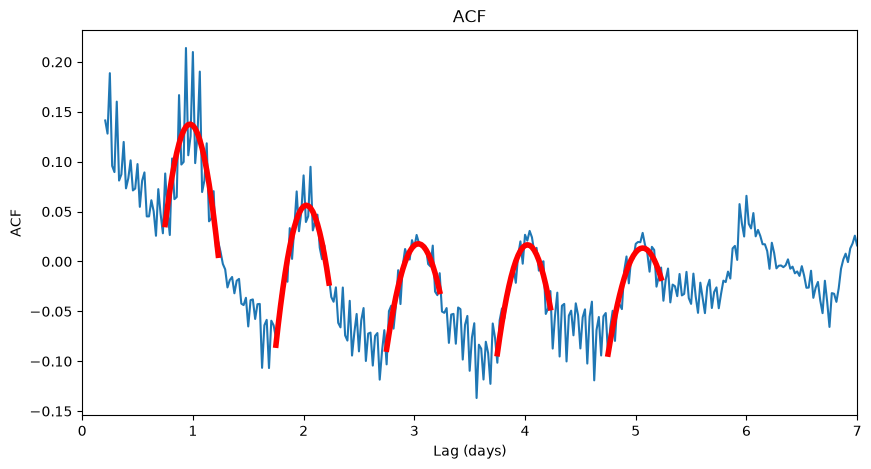

In [86]:
print(pr['P_k'] / (24*2))
ss.plot_acf(fr, pr, plot_peaks=True)

In [29]:
pr.keys()
pr['P_k'] / ()

array([408.40413076, 437.47628586, 445.01620875, 422.92680669,
       424.13822313])

In [65]:
24*60/30

48.0

Detected period: 408.3700 days


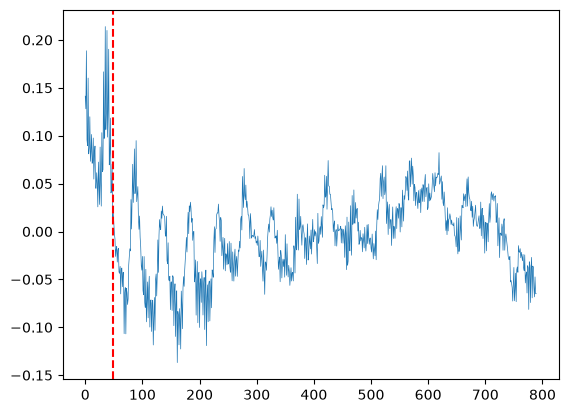

In [68]:
print(f"Detected period: {pr['P_avg']:.4f} days")
# plt.plot(fr['acf_lags'][10:(20*40)], fr['acf'][10:(20*40)], lw=0.5)
plt.plot(fr['acf'][10:(20*40)], lw=0.5)
plt.axvline(1*24*60/30, color='r', ls='--')

In [10]:
(time[1:] - time[:-1]) * 24 * 60

array([30.      , 30.      , 29.999998, ..., 30.014648, 30.014648,
       29.970703], shape=(17519,), dtype=float32)